In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings("ignore")

# College Course Data Analysis: Does Attendance Impact Student Performace?

I am an adjuct college professor in the mathematics department, typically teaching Precalculus and Finite Mathematics (a math course for business majors). Courses are taught on Monday, Wednesday, and Friday, and are set up as follows
* Two weekly assignments
    * Written Assignments: Students hand write and submit hand-written solutions to selected problems. This is graded for accuracy and requires them to show all of their work to receive full credit.
    * Webwork Assignments: Students complete practice problems in an online homework platform. These are graded for accuracy, but they are not required to show work to receive the credit.
* Quizzes: Every Monday there is a short quiz over basics of the previous weeks classes. The quiz is graded on accuracy and work, and is designed to take between 10-15 minutes.
* Exit Slips: Every Wednesday and Friday (excluding exam days) students complete an exit slip. This is a one question problem usually completed at the end of the class. This is graded only on effort not on accuracy. This is a fantastics tool to give the professor immediate feedback and students easy attendance points.
* Exams
* Final Exam

For this course, quizzes and exit slips are not allowed to be made-up. To account for expected absences and illness, two quizzes are dropped from their grade, and three exit slips are dropped from their grade. Canvas has factored the drops in to determine their current overall grade and letter grade in the course.

## Motivation

This semester I began to notice a decline in attendance in one of my courses, and I wanted an easy way see how many classes a student has attended as well as their average assignment scores and overall grade. Attendance is not explicitly taken for this course. However, attendance can be determined based on whether the student took a quiz, completed an exit slip, or took an exam.

## Acquiring The Data

I downloaded the csv file of the student gradebook from Canvas (LMS) and utilize pandas to both clean the gradebook data and calculate averages of each student's assignments.Additionally, I include the students current class (freshman, sophmore, junior, or senior) using a csv file downloaded from our school's course portal.

For privacy, the student data in the csv files here on GitHub are randomly generated. However, the structure of the files is identical to the data from Canvas and the portal.


In [ ]:
grades130_csv = "synthetic_130SP26_grades.csv"
student130_csv = "synthetic_130SP26_studentinfo.csv"
grades140_csv = "synthetic_140SP26_grades.csv"
student140_csv = 'synthetic_140SP26_studentinfo.csv'
student130FA25_csv = "synthetic_130FA25_studentinfo.csv"
grades130FA25_csv = "synthetic_130FA25_grades.csv"

### The Data

To gain familiarily, take a look at the csv files used.

In [3]:
grades = pd.read_csv(grades130_csv)
grades.head()

,Student,ID,SIS User ID,SIS Login ID,Section,Written Assignment 0 (158438),Written Assignment 1 (158439),Written Assignment 2 (158444),Written Assignment 4 (158445),Written Assignment 5 (158446),Written Assignment 6 (158447),Written Assignment 8 (158448),Written Assignment 9 (158449),Written Assignment 10 (158440),Written Assignment 12 (158441),Written Assignment 13 (158442),Written Assignment 14 (158443),Webwork 1 (158424),Webwork 2 (158430),Webwork 3 (158431),Webwork 4 (158432),Webwork 5 (158433),Webwork 6 (158434),Webwork 7 (158435),Webwork 8 (158436),Webwork 9 (158437),Webwork 10 (158425),Webwork 11 (158426),Webwork 12 (158427),Webwork 13 (158428),Webwork 14 (158429),Quiz 1 (158413),Quiz 2 (158416),Quiz 3 (158417),Quiz 4 (158418),Quiz 5 (158419),Quiz 6 (158420),Quiz 7 (158421),Quiz 8 (158422),Quiz 9 (158423),Quiz 10 (158414),Exit Slip 0 (158397),Exit Slip 1 (158398),Exit Slip 2 (158450),Exit Slip 3 (158404),Exit Slip 4 (158405),Exit Slip 5 (158406),Exit Slip 6 (158407),Exit Slip 7 (158408),Exit Slip 8 (158409),Exit Slip 9 (158410),Exit Slip 10 (158399),Exit Slip 11 (158400),Exit Slip12 (158411),Exit Slip 13 (158401),Exit Slip 14 (158402),Exit Slip 15 (158451),Exit Slip 16 (158459),Exit Slip 17 (158452),Exit Slip 18 (158458),Exit Slip 19 (158457),Exit Slip 20 (158456),Exit Slip 21 (158455),Exit Slip 23 (158454),Exit Slip 24 (158453),Exit Slip 25 (158460),Exit Slip 26 (158462),Exit Slip 27 (158461),Exit Slip 29 (158463),Exam 1 (158391),Exam 2 (158393),Exam 3 (158395),Final Exam (158412),Written Assingments Current Score,Written Assingments Unposted Current Score,Written Assingments Final Score,Written Assingments Unposted Final Score,Webwork Current Score,Webwork Unposted Current Score,Webwork Final Score,Webwork Unposted Final Score,Quizzes Current Score,Quizzes Unposted Current Score,Quizzes Final Score,Quizzes Unposted Final Score,Exit Slips Current Score,Exit Slips Unposted Current Score,Exit Slips Final Score,Exit Slips Unposted Final Score,Exam 1 Current Score,Exam 1 Unposted Current Score,Exam 1 Final Score,Exam 1 Unposted Final Score,Exam 2 Current Score,Exam 2 Unposted Current Score,Exam 2 Final Score,Exam 2 Unposted Final Score,Exam 3 Current Score,Exam 3 Unposted Current Score,Exam 3 Final Score,Exam 3 Unposted Final Score,Final Exam Current Score,Final Exam Unposted Current Score,Final Exam Final Score,Final Exam Unposted Final Score,Current Score,Unposted Current Score,Final Score,Unposted Final Score,Current Grade,Unposted Current Grade,Final Grade,Unposted Final Grade
0,Points Possible,NaN,NaN,NaN,NaN,5.0,24.0,23.0,23.0,25.0,28.0,23.0,23.0,27.0,22.0,28.0,25.0,19.00,12.0,29.0,21.0,5.0,12.0,16.0,13.0,16.0,12.0,12.0,12.0,13.0,17.0,9.0,10.0,11.0,7.00,8.00,11.0,11.0,8.0,12.0,10.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.00,3.00,3.00,3.00,3.0,3.0,3.00,3.0,3.00,3.0,3.0,3.00,3.00,3.00,3.0,3.00,3.0,60.0,57.0,68.0,120.0,(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only),(read only)
1,"Adams, Charlotte",1361520.0,3315920.0,cadams@university.edu,MATH 130 4,5.0,24.0,20.0,19.0,22.0,21.5,22.0,20.0,25.0,22.0,24.0,0.0,18.33,12.0,24.0,21.0,5.0,12.0,16.0,13.0,14.0,12.0,12.0,12.0,13.0,0.0,8.0,9.0,6.5,6.00,5.00,7.5,6.0,0.0,6.0,0.0,3.0,3.0,3.0,3.0,3.0,0.0,3.0,3.0,0.0,3.0,3.0,3.00,3.00,0.00,3.00,3.0,0.0,3.00,0.0,0.00,3.0,0.0,0.00,3.00,0.00,3.0,0.00,0.0,58.5,49.5,40.0,79.0,81.34,81.34,81.34,81.34,96.01,96.01,96.01,96.01,68.35,68.35,68.35,68.35,68.00,68.00,68.00,68.00,97.50,97.50,97.50,97.50,86.84,86.84,86.84,86.84,58.82,58.82,58.82,58.82,65.83,65.83,65.83,65.83,78.23,78.23,78.23,78.23,C+,C+,C+,C+
2,"White, Isabella",136

In [ ]:
students = pd.read_csv(student130_csv)
students.head()

,Student Name,Student ID,Class Level,Preferred Email
0,"Adams, Charlotte",3315920.0,Sophomore,cadams@university.edu
1,"Adams, Lucas",3315905.0,Freshman,ladams@university.edu
2,"Allen, Charlotte",3315903.0,Junior,callen@university.edu
3,"Baker, Amelia",3315908.0,Sophomore,abaker@university.edu
4,"Baker, Mia",3315911.0,Freshman,mbaker@university.edu


## Data Cleaning
The function below completes all cleaning and merging of the data that is necessary. Extensive commenting has provided to explain each step. A function was used rather than showing each step individual so that the cleaning and analysis could easily be done for any course.

In [5]:
def clean_class(grades_csv, student_csv):
    student = pd.read_csv(student_csv)
    grades = pd.read_csv(grades_csv)
    #some Canvas courses have a "Test Student" for the professor to "act" as a student
    #It is included in the gradebook csv, but we obviously do not want to include it here
    if ((grades["Student"] == "Student, Test").any() == True):
        grades = grades.drop(grades.index[grades["Student"] == "Student, Test"][0])
    #merge the grades csv from Canvas and the portal information csv. We merge on the student email as it is unique
    grades = pd.merge(grades.rename(columns={"SIS Login ID": "Preferred Email"}), student, how = "left", on = "Preferred Email")
    #rename columns with numbers after
    grades.columns = grades.columns.str.replace(r'\s\(.*\)', '', regex=True)
    #drop assignments not yet completed (i.e. drop columns) - this allows for analysis during the term rather than only at end
    grades = grades.dropna(axis = 1, thresh = 10)
    #Fill any remaining scores with 0 (accidently did not fill in system when absent)
    grades = grades.fillna(0.0)
    #replace excused as 0 - students are occasionally excused for sports. This zero does not impact their course grade.
    grades = grades.replace("EX", 0.0)
    #lower and snake case the column names
    grades.columns = grades.columns.str.lower().str.replace(" ", "_")
    #drop unnecessary or conflicting
    grades = grades.drop(columns=["student_name","preferred_email", "id", "student_id"])
    #grab course class percentage
    current_grades = grades.loc[:, "current_score"]
    #drop all unnecessary columns in canvas gradebook used for end of semester grading 
    grades = grades.drop(columns = grades.columns[grades.columns.str.contains("score|unposted|final", regex = True)])
    #cast all exit slip and quizzes as float. This was not inherited because of "excused" entries earlier
    grades.loc[:, grades.columns.str.startswith("exit")] = grades.loc[:, grades.columns.str.startswith("exit")].astype("float64")
    grades.loc[:, grades.columns.str.startswith("quiz")] = grades.loc[:, grades.columns.str.startswith("quiz")].astype("float64")
    #convert points scores all into percentages for later aggregation ease
    for col in grades.columns[grades.columns.str.contains("written|webwork|exam|exit|quiz", regex = True)]:
        grades.loc[1:, col] = grades.loc[1:, col]/grades.loc[0, col]
    #drop the first row which has "total possible points" for some assignments and Nan for others
    grades = grades.drop(index = 0)
    # split the student name into first and last name columns so they can be accessed separately if necessary
    grades[["last_name", "first_name"]] =  grades.loc[:,"student"].str.split(",", expand = True)
    grades.loc[:, "last_name"] = grades.loc[:, "last_name"].str.lower()
    grades.loc[:, "first_name"] = grades.loc[:, "first_name"].str.lower()
    grades.insert(0,"last_name", grades.pop("last_name"))
    grades.insert(1,"first_name", grades.pop("first_name"))
    return grades, current_grades

Below we can see the cleaned version of the data. Notice the merging of the csv files, the snake casing of the feature names, the deletion of many unnecessary features in the original Canvas gradebook file which Canvas uses, and the splitting of the student name into first and last name.

In [6]:
grades, current_grades = clean_class(grades130_csv, student130_csv)
grades.head()

,last_name,first_name,student,sis_user_id,section,written_assignment_0,written_assignment_1,written_assignment_2,written_assignment_4,written_assignment_5,written_assignment_6,written_assignment_8,written_assignment_9,written_assignment_10,written_assignment_12,written_assignment_13,written_assignment_14,webwork_1,webwork_2,webwork_3,webwork_4,webwork_5,webwork_6,webwork_7,webwork_8,webwork_9,webwork_10,webwork_11,webwork_12,webwork_13,webwork_14,quiz_1,quiz_2,quiz_3,quiz_4,quiz_5,quiz_6,quiz_7,quiz_8,quiz_9,quiz_10,exit_slip_0,exit_slip_1,exit_slip_2,exit_slip_3,exit_slip_4,exit_slip_5,exit_slip_6,exit_slip_7,exit_slip_8,exit_slip_9,exit_slip_10,exit_slip_11,exit_slip12,exit_slip_13,exit_slip_14,exit_slip_15,exit_slip_16,exit_slip_17,exit_slip_18,exit_slip_19,exit_slip_20,exit_slip_21,exit_slip_23,exit_slip_24,exit_slip_25,exit_slip_26,exit_slip_27,exit_slip_29,exam_1,exam_2,exam_3,current_grade,class_level
1,adams,charlotte,"Adams, Charlotte",3315920.0,MATH 130 4,1.0,1.000000,0.869565,0.826087,0.88,0.767857,0.956522,0.869565,0.925926,1.000000,0.857143,0.0,0.964737,1.00,0.827586,1.00000,1.0,1.0,1.0,1.0,0.8750,1.0,1.0,1.00,1.0,0.0,0.888889,0.90,0.590909,0.857143,0.625,0.681818,0.545455,0.0000,0.500000,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.975000,0.868421,0.588235,C+,Sophomore
2,white,isabella,"White, Isabella",3315909.0,MATH 130 4,0.0,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.00,0.0,0.0,1.000000,0.75,0.000000,0.0,0.0,0.000000,0.000000,0.0000,0.000000,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.616667,0.000000,0.000000,F,Senior
3,walker,theodore,"Walker, Theodore",3315918.0,MATH 130 4,1.0,0.979167,0.739130,0.934783,0.92,0.000000,0.478261,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.75,0.172414,0.97619,1.0,1.0,1.0,1.0,0.5625,0.0,0.0,0.00,0.0,0.0,1.000000,0.00,0.090909,0.0,1.0,0.000000,0.000000,0.0000,0.000000,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.508333,0.000000,0.000000,F,Junior
4,walker,mia,"Walker, Mia",3315924.0,MATH 130 4,1.0,1.000000,0.652174,1.000000,0.88,0.964286,0.956522,1.000000,1.000000,0.863636,1.000000,1.0,1.000000,1.00,0.965517,1.00000,1.0,1.0,1.0,1.0,1.0000,1.0,1.0,0.75,1.0,1.0,0.888889,0.90,0.909091,1.0,1.0,0.818182,0.909091,0.8125,0.625000,0.9,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.908333,0.973684,0.830882,A-,Senior
5,thompson,harper,"Thompson, Harper",3315928.0,MATH 130 4,1.0,1.000000,1.000000,1.000000,1.00,1.000000,1.000000,0.913043,1.000000,1.000000,0.928571,1.0,1.000000,1.00,1.000000,1.00000,1.0,1.0,0.0,1.0,1.0000,1.0,1.0,1.00,1.0,1.0,1.000000,1.00,0.363636,1.071429,1.0,0.000000,0.954545,0.6250,0.541667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.066667,1.052632,0.985294,A,Freshman


## Data Engineering
The function below completes all engineering of new features of interest such as: attendance, quiz and assignment averages, and number of completed assingments. Extensive commenting has provided to explain each step. A function was used rather than showing each step individual so that the cleaning and analysis could easily be done for any course.

In [7]:
def grades_engineer(grades, current_grades, course):
    # make attendance count using the number of exit slips and number of quizzes taken
    exit_count = grades.loc[:, grades.columns.str.startswith("exit_slip")].T.sum()
    quiz = grades.loc[:, grades.columns.str.startswith("quiz")]
    quiz[quiz>0] = 1.0
    quiz_count = quiz.T.sum()
    grades.loc[:,grades.columns.str.startswith("exam")] = grades.loc[:,grades.columns.str.startswith("exam")].astype("float64")
    grades["lect_attend"] = round((exit_count+quiz_count).astype("float64"),3)
    grades["lect_attend_perc"] = round((grades["lect_attend"]/len(grades.columns[grades.columns.str.contains("quiz|exit", regex = True)])).astype("float64"),3)
    grades["absences"] = (len(grades.columns[grades.columns.str.contains("quiz|exit", regex = True)])-grades["lect_attend"]).astype("float64")
    grades = grades.drop(columns=grades.columns[grades.columns.str.contains("exit", regex = True)]) #drop the exit slips

    # make the averages for written, quiz, and webwork
    grades["written_avg"] = round((grades.loc[:, grades.columns.str.startswith("written")].T.sum())/len(grades.columns[grades.columns.str.startswith("written")]),3)
    quiz1 = grades.loc[:, grades.columns.str.startswith("quiz")].astype("float64")
    quiz1 = quiz1.T.sum()
    grades["quiz_avg"] = round((quiz1/len(grades.columns[grades.columns.str.startswith("quiz")])).astype("float64"),3)
    grades["web_avg"] = round((grades.loc[:, grades.columns.str.startswith("web")].T.sum())/len(grades.columns[grades.columns.str.startswith("web")]),3)
    web = grades.loc[:, grades.columns.str.startswith("web")]
    grades["web_avg"] = round((grades.loc[:, grades.columns.str.startswith("web")].T.sum())/len(grades.columns[grades.columns.str.startswith("web")]),3)
    
    # written count & webwork count
    grades.loc[:,grades.columns.str.startswith("written")] = grades.loc[:,grades.columns.str.startswith("written")].astype("float64")
    written = grades.loc[:, grades.columns.str.startswith("written")]
    written[written>0] = 1.0
    written_count = written.T.sum()
    grades["writ_total"] = len(grades.columns[grades.columns.str.startswith("written")])
    grades["writ_count"] = written_count
    grades.loc[:,grades.columns.str.startswith("webwork")] = grades.loc[:,grades.columns.str.startswith("webwork")].astype("float64")
    web = grades.loc[:, grades.columns.str.startswith("webwork")]
    web[web>0] = 1.0
    web_count = web.T.sum()
    grades["web_total"] = len(grades.columns[grades.columns.str.startswith("web")])
    grades["web_count"] = web_count
    
    # add the course date as entered
    grades["course_date"] = course
    for col in grades.columns[grades.columns.str.startswith("exam")]:
        grades.loc[:, col] = round(grades.loc[:,col],3)
        grades.insert(len(grades.columns)-2,col, grades.pop(col))
    #insert the total grade column back (previously deleted for ease of cleaning)
    grades.insert(len(grades.columns)-2,"total_grade", current_grades)
    grades = grades.drop(columns= "student")
    grades["total_grade"] = grades["total_grade"].astype("float64")/100
    # subset the dataframe to return a subframe of just averages attendace
    sub_col = ["first_name", "last_name", "lect_attend", "lect_attend_perc", "absences", "writ_count", "writ_total","web_count", "web_total", "written_avg","quiz_avg", "web_avg"] + list(grades.columns[grades.columns.str.startswith("exam")]) + ["total_grade", "current_grade", "class_level", "section", "course_date"]
    grades_sub = grades.loc[:, sub_col]
    return grades, grades_sub

def main(grades_csv, student_csv, course):
    grades,current_grades =  clean_class(grades_csv, student_csv)
    return grades_engineer(grades, current_grades, course)

We see that only the engineered features and necessaryy features are included. The newly engineered features are:
* lect_attend  = number of attended lectures
* lect_attend_perc = percentage of attended lectures
* absences = number of lecture absences
* writ_count = number submitted written assignments
* web_count = number of submitted webworks
* writ_avg  = average percentage on a written assignments
* web_avg = average percentage on a webwork
* quiz_avg = average perecntage on a quizzes

In [8]:
grades130SP, grades130SP_sub = main(grades130_csv, student130_csv, "130SP26")
grades130SP_sub.head()

,first_name,last_name,lect_attend,lect_attend_perc,absences,writ_count,writ_total,web_count,web_total,written_avg,quiz_avg,web_avg,exam_1,exam_2,exam_3,total_grade,current_grade,class_level,section,course_date
1,charlotte,adams,25.0,0.658,13.0,12.0,13,13.0,15,0.829,0.559,0.905,0.975,0.868,0.588,0.7823,C+,Sophomore,MATH 130 4,130SP26
2,isabella,white,4.0,0.105,34.0,0.0,13,0.0,15,0.000,0.175,0.000,0.617,0.000,0.000,0.1188,F,Senior,MATH 130 4,130SP26
3,theodore,walker,10.0,0.263,28.0,7.0,13,9.0,15,0.421,0.209,0.533,0.508,0.000,0.000,0.2233,F,Junior,MATH 130 4,130SP26
4,mia,walker,27.0,0.711,11.0,13.0,13,14.0,15,0.943,0.876,0.980,0.908,0.974,0.831,0.9115,A-,Senior,MATH 130 4,130SP26
5,harper,thompson,33.0,0.868,5.0,13.0,13,13.0,15,0.987,0.756,0.929,1.067,1.053,0.985,0.9830,A,Freshman,MATH 130 4,130SP26


## Data Analysis

Now, we use our functions above to transform the data downloaded from Canvas and the school portal all in one step.

The tranfomation is completed for multiple courses so that I may search and compare to previous courses

In [ ]:
grades130_csv = "synthetic_130SP26_grades.csv"
student130_csv = "synthetic_130SP26_studentinfo.csv"
grades140_csv = "synthetic_140SP26_grades.csv"
student140_csv = 'synthetic_140SP26_studentinfo.csv'
student130FA25_csv = "synthetic_130FA25_studentinfo.csv"
grades130FA25_csv = "synthetic_130FA25_grades.csv"

grades130SP, grades130SP_sub = main(grades130_csv, student130_csv, "130SP26")
grades130FA, grades130FA_sub = main(grades130FA25_csv, student130FA25_csv, "130FA25")
grades140SP, grades140SP_sub = main(grades140_csv, student140_csv, "140SP26")

grades_all = pd.concat([grades130SP_sub, grades130FA_sub, grades140SP_sub], axis = 0)

Let's take a look at the newly cleaned data and newly constructed features

In [10]:
grades_all.head()

,first_name,last_name,lect_attend,lect_attend_perc,absences,writ_count,writ_total,web_count,web_total,written_avg,quiz_avg,web_avg,exam_1,exam_2,exam_3,total_grade,current_grade,class_level,section,course_date
1,charlotte,adams,25.0,0.658,13.0,12.0,13,13.0,15,0.829,0.559,0.905,0.975,0.868,0.588,0.7823,C+,Sophomore,MATH 130 4,130SP26
2,isabella,white,4.0,0.105,34.0,0.0,13,0.0,15,0.000,0.175,0.000,0.617,0.000,0.000,0.1188,F,Senior,MATH 130 4,130SP26
3,theodore,walker,10.0,0.263,28.0,7.0,13,9.0,15,0.421,0.209,0.533,0.508,0.000,0.000,0.2233,F,Junior,MATH 130 4,130SP26
4,mia,walker,27.0,0.711,11.0,13.0,13,14.0,15,0.943,0.876,0.980,0.908,0.974,0.831,0.9115,A-,Senior,MATH 130 4,130SP26
5,harper,thompson,33.0,0.868,5.0,13.0,13,13.0,15,0.987,0.756,0.929,1.067,1.053,0.985,0.9830,A,Freshman,MATH 130 4,130SP26


## Data Analysis

We can first look at students who attend less than 60% of classes in the spring MATH 130 course

In [11]:
grades_all[(grades_all["lect_attend_perc"]< .6) & (grades_all["course_date"] == "130SP26")]

,first_name,last_name,lect_attend,lect_attend_perc,absences,writ_count,writ_total,web_count,web_total,written_avg,quiz_avg,web_avg,exam_1,exam_2,exam_3,total_grade,current_grade,class_level,section,course_date
2,isabella,white,4.0,0.105,34.0,0.0,13,0.0,15,0.000,0.175,0.000,0.617,0.000,0.000,0.1188,F,Senior,MATH 130 4,130SP26
3,theodore,walker,10.0,0.263,28.0,7.0,13,9.0,15,0.421,0.209,0.533,0.508,0.000,0.000,0.2233,F,Junior,MATH 130 4,130SP26
6,william,thomas,18.0,0.474,20.0,13.0,13,14.0,15,0.964,0.261,0.993,0.883,1.000,0.691,0.8099,B-,Senior,MATH 130 4,130SP26
7,harper,thomas,17.0,0.447,21.0,2.0,13,0.0,15,0.083,0.308,0.000,0.633,0.395,0.000,0.2172,F,Senior,MATH 130 4,130SP26
8,henry,scott,0.0,0.000,38.0,3.0,13,4.0,15,0.135,0.000,0.286,0.000,0.000,0.000,0.0374,F,Junior,MATH 130 4,130SP26
10,emma,scott,20.0,0.526,18.0,7.0,13,11.0,15,0.449,0.392,0.778,0.458,0.667,0.838,0.6388,D,Junior,MATH 130 4,130SP26
16,noah,jackson,2.0,0.053,36.0,3.0,13,1.0,15,0.163,0.000,0.071,0.000,0.000,0.000,0.0288,F,Freshman,MATH 130 4,130SP26
19,william,hall,9.0,0.237,29.0,5.0,13,7.0,15,0.293,0.338,0.446,0.967,1.018,0.000,0.4353,F,Freshman,MATH 130 4,130SP26
22,charlotte,hall,1.0,0.026,37.0,2.0,13,0.0,15,0.083,0.000,0.000,0.000,0.000,0.000,0.0045,F,Junior,MATH 130 4,130SP26
23,mia,baker,16.0,0.421,22.0,6.0,13,2.0,15,0.356,0.561,0.125,0.850,0.746,0.522,0.5485,F,Freshman,MATH 130 4,130SP26


We can see the letter grade distribution.

In [12]:
grades_all[grades_all["course_date"] == "130SP26"].value_counts(subset= ["current_grade"]).sort_index()

current_grade
A                 3
A-                1
B+                3
B-                2
C                 1
C+                2
C-                2
D                 4
F                10
Name: count, dtype: int64

The function below allows for me to search for one or more students' information using their last name. In practice there are not as many duplicated last namaes so this is a practical function. The synthetic data generated has many repeated names, so it's not as helpful.

In [13]:
def search_name(grades_all, last: str | list):
    if isinstance(last, str):
        return grades_all[grades_all["last_name"] == last]
    else:
        run_tot = grades_all[grades_all["last_name"] == last[0]]
        for i in range(1,len(last)):
            run_tot = pd.concat([run_tot, grades_all[grades_all["last_name"] == last[i]]])
        return run_tot.sort_values(by = "last_name")

In [14]:
#search_name(grades_all, "loomis")
search_name(grades_all, ["adams"])

,first_name,last_name,lect_attend,lect_attend_perc,absences,writ_count,writ_total,web_count,web_total,written_avg,quiz_avg,web_avg,exam_1,exam_2,exam_3,total_grade,current_grade,class_level,section,course_date
1,charlotte,adams,25.0,0.658,13.0,12.0,13,13.0,15,0.829,0.559,0.905,0.975,0.868,0.588,0.7823,C+,Sophomore,MATH 130 4,130SP26
26,lucas,adams,25.0,0.658,13.0,11.0,13,13.0,15,0.764,0.647,0.821,0.842,0.711,0.478,0.7102,C-,Freshman,MATH 130 4,130SP26


It would be interesting to compare the average course grade and lecture attendance for each course:

In [15]:
grades_all.pivot_table( index = "course_date", values=["lect_attend_perc", "total_grade"], margins=True)

,lect_attend_perc,total_grade
course_date,,
130FA25,0.816629,0.769394
130SP26,0.549857,0.603871
140SP26,0.812926,0.757748
All,0.732522,0.714404


Additionally, we could consider splitting the table by class level, so we can see if there is a difference in attendence and total grades across class level.

In [16]:
grades_all.groupby(["course_date","class_level"])[["lect_attend_perc", "absences", "total_grade"]].mean()

lect_attend_perc   absences  total_grade
course_date class_level                                          
130FA25     Freshman             0.851125   3.875000     0.846500
            Junior               0.787154   5.538462     0.694908
            Senior               0.829857   4.428571     0.777443
            Sophomore            0.818714   4.714286     0.811557
130SP26     Freshman             0.500000  19.000000     0.598183
            Junior               0.324500  25.666667     0.303917
            Senior               0.631700  14.000000     0.673350
            Sophomore            0.688667  11.833333     0.793717
140SP26     Freshman             0.908429   3.571429     0.773686
            Junior               0.736286  10.285714     0.776900
            Senior               0.812000   7.333333     0.790200
            Sophomore            0.800000   7.800000     0.723450

In [17]:
grades_all.pivot_table( index = "course_date", values="lect_attend_perc", columns = ["class_level"], margins=True)

class_level,Freshman,Junior,Senior,Sophomore,All
course_date,,,,,
130FA25,0.851125,0.787154,0.829857,0.818714,0.816629
130SP26,0.500000,0.324500,0.631700,0.688667,0.549857
140SP26,0.908429,0.736286,0.812000,0.800000,0.812926
All,0.769905,0.666692,0.728100,0.776652,0.732522


In the end, this is an incredibly helpful tool that allows me to gain instant feedback at any point throughout the semester as to how my students are performing in regards to certain metrics.

We can even take a look at correlations. Below, we see a high correlation between every variable and the students' total grades.

In [18]:
numeric = ["lect_attend", "lect_attend_perc", "written_avg", "web_avg", "quiz_avg", "exam_1", "exam_2", "exam_3", "total_grade"]
corr_matrix = grades_all[numeric].corr()
corr_matrix["total_grade"]

lect_attend         0.736280
lect_attend_perc    0.835334
written_avg         0.858995
web_avg             0.848901
quiz_avg            0.837402
exam_1              0.822104
exam_2              0.861280
exam_3              0.913919
total_grade         1.000000
Name: total_grade, dtype: float64

Visualizing this with scatterplots below, we confirm the correlation we calculated

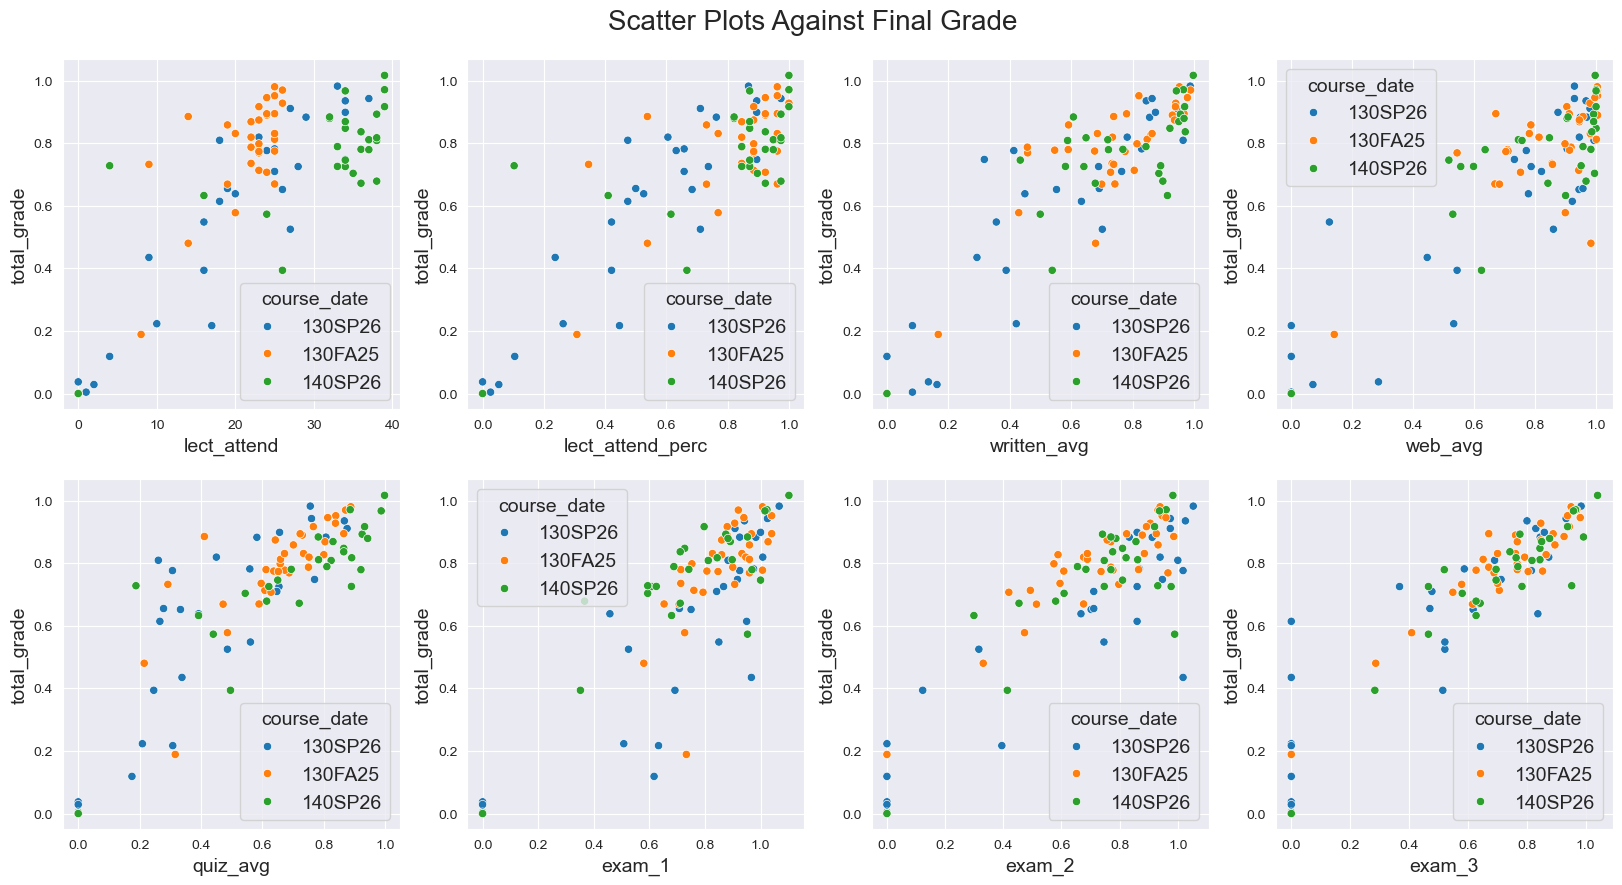

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
latex_blue = (0,80/256,115/256)

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
count = 0
# for i in range(0,2):
#     for j in range(0,3):
#         axs[i,j].set_xlabel(numeric_labels[count])
#         axs[i,j].set_ylabel("Period 3 Grade")
#         count +=1
rgb_colors_custom = [(0,80/256,115/256), (255/256, 127/256, 80/256), (100/256, 50/256, 80/256)]
plt.suptitle("Scatter Plots Against Final Grade", fontsize = 20, y = .93)
for i in range(0,2):
    for j in range(0,4):
        sns.scatterplot(data=grades_all, x=numeric[count], y = "total_grade", color= latex_blue, hue = "course_date", ax=axs[i, j])
        count +=1

plt.show()

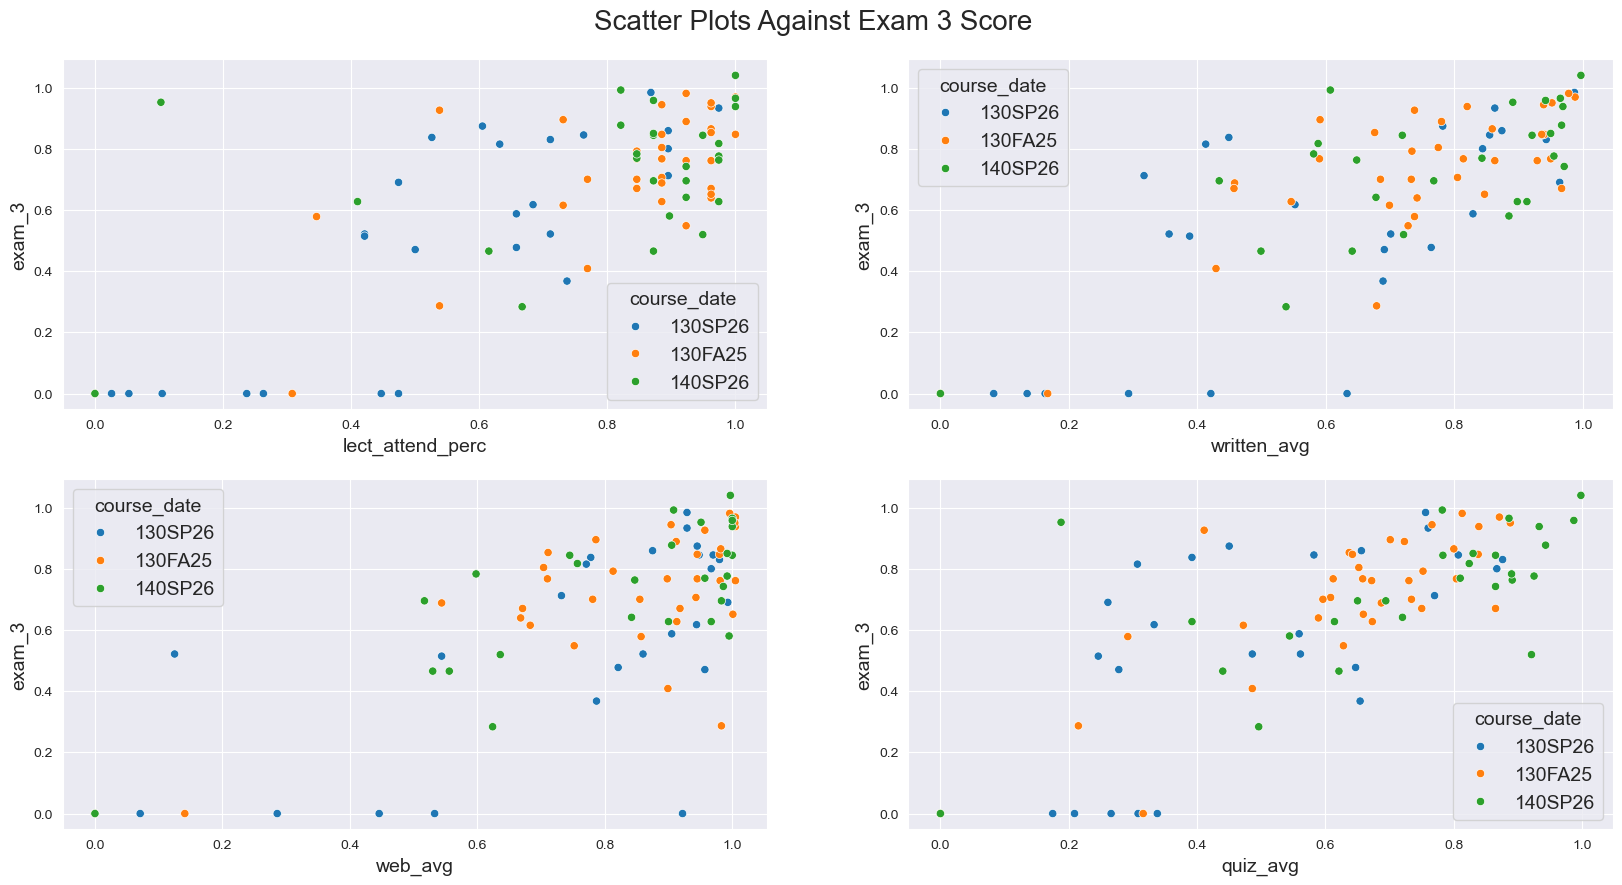

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
latex_blue = (0,80/256,115/256)

fig, axs = plt.subplots(2, 2, figsize=(20, 10))
# numeric_att = ["G1", "G2", "G3", "absences_G1", "absences_G2", "absences_G3", "sum_absences" "age", "failures"]
# numeric_labels = ["Period 1 Grade", "Period 2 Grade", "Absences for Entire Year", "Absences in Period 1", "Absences in Period 2", "Absences in Period 3"]
count = 0
# for i in range(0,2):
#     for j in range(0,3):
#         axs[i,j].set_xlabel(numeric_labels[count])
#         axs[i,j].set_ylabel("Period 3 Grade")
#         count +=1
numeric = ["lect_attend_perc", "written_avg", "web_avg", "quiz_avg"]

rgb_colors_custom = [(0,80/256,115/256), (255/256, 127/256, 80/256), (100/256, 50/256, 80/256)]
plt.suptitle("Scatter Plots Against Exam 3 Score", fontsize = 20, y = .93)
for i in range(0,2):
    for j in range(0,2):
        sns.scatterplot(data=grades_all, x=numeric[count], y = "exam_3", color= latex_blue, hue = "course_date", ax=axs[i, j])
        count +=1

plt.show()